# Experiment of CLM with or without Refinement Block on New framework MME embeddings **(only Foundation)**

In [1]:
import sys
import os

project_path = "/home/sagemaker-user/gbm_hackathon"
if project_path not in sys.path:
    sys.path.append(project_path)
    print(sys.path)

['/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python310.zip', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/lib-dynload', '', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages', '/home/sagemaker-user/gbm_hackathon']


In [2]:
%load_ext autoreload
%autoreload 2

from gbmhackathon.training.predictive import *
from gbmhackathon.models.mme import MultiModalEncoder, ClinicalLinkageModule, concat_modality_embeddings
from gbmhackathon.utils.loss_functions import InfoNCELoss, RegularizedInfoNCELoss, SmoothingFunction, RankMe, make_patient_map, RegularizationModule
from gbmhackathon.utils.module_functions import instantiate
from gbmhackathon.utils.model_saving import *
from gbmhackathon.training.loops import modality_wise_contrastive_learning, new_predictive_learning, build_run_name
from gbmhackathon.training.cv import *
from gbmhackathon.utils.analysis import *
from gbmhackathon.viz.viz_experiment import *
from gbmhackathon.s3_loader import load_s3

import os, time
from copy import deepcopy
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
# To investigate gradients
from torchviz import make_dot

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam

In [3]:
torch.set_num_threads(32)
torch.get_num_threads()

32

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)

## Dataset preparation

In [5]:
ALL_POSSIBLE_EMBS = ["025-03-22_12-27_phikon_emb_V1.pkl",
                    "2025-03-23_18-32_spatial_emb_V1.pkl",
                    "2025-03-30_14-23_clinical_emb_V1.pkl",
                    "2025-04-05_13-40_wes_emb_V1.pkl",
                    "2025-04-26_16-02_connectivities_spatial_V1.pkl",
                    "2025-05-03_10-15_bulk_emb_V1.pkl",
                    "2025-05-04_02-35_scRNA_emb_V1.pkl",
                    "2025-05-25_14-36_new_clinical_emb_V1.pkl",
                    "2025-06-01_15-11_bulk_emb_V1_mds.pkl",
                    "2025-06-01_15-11_bulk_emb_V1_pca.pkl",
                    "2025-06-01_15-11_bulk_emb_V1_umap.pkl",
                    "2025-06-01_15-11_embeddings_HnE_OptimusH0_mds.pkl",
                    "2025-06-01_15-11_embeddings_HnE_OptimusH0_pca.pkl",
                    "2025-06-01_15-11_embeddings_HnE_OptimusH0_umap.pkl",
                    "2025-06-01_15-11_scRNA_emb_V1_mds.pkl",
                    "2025-06-01_15-11_scRNA_emb_V1_pca.pkl",
                    "2025-06-01_15-11_scRNA_emb_V1_umap.pkl",
                    "2025-06-01_15-11_wes_emb_V1_mds.pkl",
                    "2025-06-01_15-11_wes_emb_V1_pca.pkl",
                    "2025-06-01_15-11_wes_emb_V1_umap.pkl",
                    "2025-06-01_18-36_raw_bulk_emb_mds.pkl",
                    "2025-06-01_18-36_raw_bulk_emb_pca.pkl",
                    "2025-06-01_18-36_raw_bulk_emb_umap.pkl",
                    "2025-06-01_21-03_raw_spatial_emb_pca.pkl",
                    "2025-06-01_22-10_raw_spatial_emb_umap.pkl",
                    "2025-06-02_21-09_raw_scRNA_emb_pca.pkl",
                    "2025-06-02_22-50_raw_scRNA_emb_umap.pkl",
                    "embeddings_HnE_OptimusH0.pkl"]

### You can choose any embedding from the above

In [6]:
name_emb_dict = {"hne":"embeddings_HnE_OptimusH0.pkl",
"spatial":"2025-03-23_18-32_spatial_emb_V1.pkl",
"clinical":"2025-05-25_14-36_new_clinical_emb_V1.pkl", # Needed to retrieve targets, will be removed afterwards
"bulk":"2025-05-03_10-15_bulk_emb_V1.pkl",
"scRNA":"2025-05-04_02-35_scRNA_emb_V1.pkl"
                }
pkl_storage_folder = "embedding_V1"

In [7]:
dataset = PredictiveLearningDataset(name_emb_dict, pkl_storage_folder, 
                                    device=device, 
                                    dropout=1.0, 
                                    normalize=True, 
                                    remove_clinical=True)
print(f"Dataset size: {len(dataset)}")
BATCH_SIZE = 742 #582
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True, collate_fn=collate_predictive, generator=torch.Generator(device=dataset.device))

cas 2 : device reconnu : cuda 
Using device: cuda
dict_keys(['hne', 'spatial', 'bulk', 'scRNA'])
Clinical successfully removed
spatial tensor([-1.2553, -1.1431, -1.0777, -1.2676, -0.8982, -1.1545, -0.8487, -1.2577,
        -0.9547, -1.1874, -1.0252, -1.2998, -1.3097, -1.2077, -1.3141, -1.2162,
        -1.0057, -1.2872, -0.9572, -1.0273, -1.0509, -1.0739, -0.9225, -1.1718,
        -1.1085, -1.2474, -1.2076, -1.3897, -1.0923, -1.1740, -1.0682, -1.4825,
        -1.2190, -1.1134, -0.9512, -1.2223, -0.9888, -1.1704, -0.9840, -1.0893,
        -1.2488, -1.1461, -1.0863, -1.0485, -1.1140, -0.9333, -1.0830, -1.0695,
        -1.1005, -0.9239, -1.3218, -0.9554, -1.0725, -1.1427, -1.0236, -1.1748,
        -0.9028, -1.0569, -1.0684, -1.0735, -0.9262, -1.0439, -0.9128, -1.0088,
        -1.0696, -1.1391, -0.8199, -0.8497, -1.4329, -1.0332, -0.8422, -1.0564,
        -1.0540, -0.9929, -0.9593, -1.2920, -1.2158, -1.0403, -0.9243, -1.1929,
        -0.9487, -1.1276, -1.3280, -0.8531, -1.1883, -1.0247], de

### To make a batch of True patient samples only (no dropout)

In [8]:
# Batch of all true samples (no dropout augmented samples)
batch_all = [dataset.__getitem__(idx) for idx in dataset.ind2patient if 'd' not in dataset.ind2patient[idx]]
batch_all = collate_predictive(batch_all)

### Needed to know the size of the inputs (it is used later on to define model configurations)

In [9]:
raw_emb = next(iter(dataloader))[2]
inpute_size_dict = {}
for mod in raw_emb.keys():
    print(mod, raw_emb[mod].size())
    inpute_size_dict[mod] = raw_emb[mod].size(1)

hne torch.Size([201, 1536])
spatial torch.Size([201, 64])
bulk torch.Size([201, 3072])
scRNA torch.Size([201, 3072])


### Patient map is used by the contrastive loss to identify dropout and true samples which are from the same original patient

In [10]:
patient_map = make_patient_map(dataset)

In [11]:
dataset_II = PredictiveLearningDataset(name_emb_dict, pkl_storage_folder, 
                                    device=device, 
                                    dropout=0.0, 
                                    normalize=True, 
                                    remove_clinical=True)
print(f"Dataset size: {len(dataset_II)}")

cas 2 : device reconnu : cuda 
Using device: cuda
dict_keys(['hne', 'spatial', 'bulk', 'scRNA'])
Clinical successfully removed
spatial tensor([-1.2553, -1.1431, -1.0777, -1.2676, -0.8982, -1.1545, -0.8487, -1.2577,
        -0.9547, -1.1874, -1.0252, -1.2998, -1.3097, -1.2077, -1.3141, -1.2162,
        -1.0057, -1.2872, -0.9572, -1.0273, -1.0509, -1.0739, -0.9225, -1.1718,
        -1.1085, -1.2474, -1.2076, -1.3897, -1.0923, -1.1740, -1.0682, -1.4825,
        -1.2190, -1.1134, -0.9512, -1.2223, -0.9888, -1.1704, -0.9840, -1.0893,
        -1.2488, -1.1461, -1.0863, -1.0485, -1.1140, -0.9333, -1.0830, -1.0695,
        -1.1005, -0.9239, -1.3218, -0.9554, -1.0725, -1.1427, -1.0236, -1.1748,
        -0.9028, -1.0569, -1.0684, -1.0735, -0.9262, -1.0439, -0.9128, -1.0088,
        -1.0696, -1.1391, -0.8199, -0.8497, -1.4329, -1.0332, -0.8422, -1.0564,
        -1.0540, -0.9929, -0.9593, -1.2920, -1.2158, -1.0403, -0.9243, -1.1929,
        -0.9487, -1.1276, -1.3280, -0.8531, -1.1883, -1.0247], de

## Load Trained MME with new framework

In [12]:
model_path = '../saved_models/new_onlyFoundation_mme.ckpt'
cfg_model_path = '../saved_models/cfg_new_onlyFoundation_mme.ckpt'
mme = load_model(MultiModalEncoder, model_path, cfg_model_path, device=dataset_II.device, training=False)

{'net_type': 'mlp', 'device': device(type='cuda'), 'net_config': {'layers': [1536, 512, 128, 32], 'dropout': 0.3, 'act_fn': [<class 'torch.nn.modules.activation.GELU'>, <class 'torch.nn.modules.activation.GELU'>, None], 'norm_layer': <class 'torch.nn.modules.batchnorm.BatchNorm1d'>, 'device': 'cuda'}}
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found

Model succesfully loaded on device cuda. Model currently in inference mode.


In [13]:
# Retrieve the output size of each encoder in the MME
all_encoder_output_sizes = [mme.config[mod_cfg]['net_config']['layers'][-1] for mod_cfg in mme.config.keys() if mme.config[mod_cfg] is not None]
output_size = int(np.sum(all_encoder_output_sizes).item())

### Configuration of the clinical linkage module

In [14]:
dropout = 0.2
layers = [output_size,1024,512,128]
act_fn = [nn.GELU] * (len(layers) - 1) + [None]
norm_fn = nn.BatchNorm1d
reg_head_cfg = {"layers": layers + [1],
        "dropout": dropout,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}
binary_clf_head_cfg = {"layers": layers + [2],
        "dropout": dropout,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}
multi_clf_head_cfg = {"layers": layers + [3],
        "dropout": dropout,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}

In [15]:
os_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
pfs_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
recurrency_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": binary_clf_head_cfg}
mgmt_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": multi_clf_head_cfg}

In [16]:
# ATTENTION !!!! MUST BE THIS EXACT ORDER FOR PREDICTIVE TASKS: 
# ['os_years', 'pfs_years', 'largest_diameter_of_the_primary_tumour_mm_duplicated_0', 'recurrent_sample']
# OR ['os_years', 'pfs_years', 'recurrent_sample', 'mgmt_promoter_methylation'] if using latest targets
predictive_cfg = {"heads_configs":{"os": os_head_cfg,
                  "pfs": pfs_head_cfg,
                  "recurrency":recurrency_head_cfg,
                  "mgmt":mgmt_head_cfg}}

clf_targets = ['recurrency', 'mgmt']
clf_targets_dict = {'recurrency':2, 'mgmt':3}

### Let's try with a refinement block

In [17]:
refinement_cfg = {"emb_size": output_size,
                "cross_modality_heads": 1,
                "cross_mods_fc_size": 128,
                "avail_mods_fc_size": 32,
                "avail_mods_len":len(all_encoder_output_sizes),
                "avail_mods_dense_size": 32,
                "avail_mods_heads": 1,
                "act_fn": nn.GELU,
                "dropout": dropout,
                "device": device}

# Monte Carlo Cross Validation
Instantiation must be done for each fold

In [18]:
n_splits = 30
test_size = 0.8
t_batch = 32 # training batch size
v_batch = 256 # evaluation batch size
random_state = 6262

In [19]:
cv_scores = {task:[] for task in predictive_cfg["heads_configs"].keys()}
t0 = time.time()
for train_loader, val_loader in get_mccv_loaders(dataset_II, 
                                                 collate_predictive,
                                                 n_splits=n_splits, 
                                                 test_size=test_size, 
                                                 train_batch_size=t_batch, 
                                                 val_batch_size=v_batch, 
                                                 device=device, 
                                                 random_state=random_state):
    EPOCHS_II = 150
    base_lr_II = 1e-4
    eta_min_coef = 0.05
    scheduler_II_class = torch.optim.lr_scheduler.CosineAnnealingLR
    scheduler_II_cfg = {"T_max":EPOCHS_II,
                        "eta_min":"dynamic"}
    clm = ClinicalLinkageModule(refinement_cfg=refinement_cfg,
                            predictive_cfg=predictive_cfg)
    # Optimization for Phase II
    optimizer_II = Adam(clm.parameters(), lr=base_lr_II)
    scheduler_II_cfg["optimizer"] = optimizer_II
    if "eta_min" in scheduler_II_cfg.keys():
        if scheduler_II_cfg["eta_min"] == "dynamic":
            scheduler_II_cfg["eta_min"] = eta_min_coef * base_lr_II
    scheduler_II = instantiate(scheduler_II_cfg, scheduler_II_class)

    # Training loop with validation at the end of each epoch on the validation set
    new_predictive_learning(mme, clm, 
                          train_loader,
                          EPOCHS_II, 
                          base_lr_II, 
                          optimizer_II,
                          scheduler_II,
                          clf_targets_dict,
                          v_dataloader=val_loader,
                          reg_loss_fn = nn.MSELoss(),
                          clf_loss_fn = nn.CrossEntropyLoss(),
                          batch_all=batch_all, # No worries, it is used in eval mode under the hood so not seen by model
                          make_gifs=False,
                          )
    # Evaluation metrics are computed on the validation set after training.
    clm.eval()
    all_val_predictions = {task:[] for task in predictive_cfg["heads_configs"].keys()}
    all_val_targets = {task:[] for task in predictive_cfg["heads_configs"].keys()}
    for batch in val_loader:
        patient_ids, modalities, X_dict, avail_mods, batch_targets, targets_names = batch
        
        contrastive_outputs = mme(X_dict)
        task_outputs, patient_embeddings = clm(contrastive_outputs, avail_mods)
        
        overall_loss = torch.tensor(0, device=device)
        # Regression losses
        for i, key in enumerate(task_outputs.keys()):
            if key not in clf_targets:
                all_val_predictions[key].append(task_outputs[key].squeeze())
                all_val_targets[key].append(batch_targets[:,i])
            
        # Classification losses
        for i, key in enumerate(clf_targets):
            if i == 0:
                start_idx = len(task_outputs.keys()) - len(clf_targets)
            else:
                start_idx = end_idx - 1 # last end_idx
            # clf_targets_dict is a dict that maps each clf target to the number of classes it holds
            end_idx = start_idx + clf_targets_dict[key]
            all_val_predictions[key].append(task_outputs[key])
            all_val_targets[key].append(batch_targets[:,start_idx:end_idx])
            
    for task in all_val_predictions.keys():
        all_task_pred = torch.cat(all_val_predictions[task], dim=0).to(dataset.device)
        all_task_true = torch.cat(all_val_targets[task], dim=0).to(dataset.device)
        if task not in clf_targets:
            score = torch.sqrt(nn.MSELoss()(all_task_pred, all_task_true)).item()
        else:
            score = f1_score(torch.argmax(all_task_true, dim=1).cpu().detach().numpy(), 
                             torch.argmax(all_task_pred, dim=1).cpu().detach().numpy(), 
                             average='weighted', zero_division=0)
        cv_scores[task].append(score)
reg_dict = {key:val for key, val in cv_scores.items() if key in ['os', 'pfs']}
clf_dict = {key:val for key, val in cv_scores.items() if key in clf_targets}
runtime = time.time() - t0

Using device: cuda
Using device(prediction head) : cuda
Using device(prediction head) : cuda
Using device(prediction head) : cuda
Using device(prediction head) : cuda
EPOCH 1 TOTAL TRAINING LOSS: 5.9995
EPOCH 2 TOTAL TRAINING LOSS: 5.699755
EPOCH 3 TOTAL TRAINING LOSS: 4.470043
EPOCH 4 TOTAL TRAINING LOSS: 4.569432
EPOCH 5 TOTAL TRAINING LOSS: 3.101930
EPOCH 6 TOTAL TRAINING LOSS: 4.474449
EPOCH 7 TOTAL TRAINING LOSS: 3.494367
EPOCH 8 TOTAL TRAINING LOSS: 3.452570
EPOCH 9 TOTAL TRAINING LOSS: 2.638895
EPOCH 10 TOTAL TRAINING LOSS: 2.79930
EPOCH 11 TOTAL TRAINING LOSS: 3.502609
EPOCH 12 TOTAL TRAINING LOSS: 2.187338
EPOCH 13 TOTAL TRAINING LOSS: 3.074248
EPOCH 14 TOTAL TRAINING LOSS: 3.458159
EPOCH 15 TOTAL TRAINING LOSS: 2.326277
EPOCH 16 TOTAL TRAINING LOSS: 2.792689
EPOCH 17 TOTAL TRAINING LOSS: 1.966303
EPOCH 18 TOTAL TRAINING LOSS: 2.680116
EPOCH 19 TOTAL TRAINING LOSS: 2.392538
EPOCH 20 TOTAL TRAINING LOSS: 2.314156
EPOCH 21 TOTAL TRAINING LOSS: 2.580869
EPOCH 22 TOTAL TRAINING LO

In [20]:
run_name = build_run_name(
    model=clm,
    epochs=EPOCHS_II,
    base_lr=base_lr_II,
    eta_min_coef=eta_min_coef,
    scheduler_class=scheduler_II_class,
    scheduler_cfg=scheduler_II_cfg,
    contrastive_loss_cfg=None,
    modality_list=list(name_emb_dict.keys())
)

In [21]:
get_cv_results(reg_dict, clf_dict, 'new_onlyFoundation_' + run_name, time=runtime, save=True)

,run,n_folds,time,low_rmse_os,avg_rmse_os,up_rmse_os,low_rmse_pfs,avg_rmse_pfs,up_rmse_pfs,low_f1_recurrency,avg_f1_recurrency,up_f1_recurrency,low_f1_mgmt,avg_f1_mgmt,up_f1_mgmt,sum_reg_avg,sum_clf_avg,sum_reg_ci_relative_width,sum_clf_ci_relative_width
0,new_onlyFoundation_ClinicalLinkageModule_E150_...,30,369.73889,1.120793,1.158661,1.217141,1.100144,1.144744,1.195403,0.495427,0.513141,0.533789,0.401848,0.429467,0.453235,2.303405,0.942608,0.166369,0.194411


## **Results**

In [22]:
evaluations = {}
for task in cv_scores.keys():
    evaluations[task] = np.mean(cv_scores[task])
    print(f"MCCV score on task {task}: {evaluations[task]}")

MCCV score on task os: 1.1586608091990154
MCCV score on task pfs: 1.1447438279787698
MCCV score on task recurrency: 0.513140999722231
MCCV score on task mgmt: 0.4294673108242067


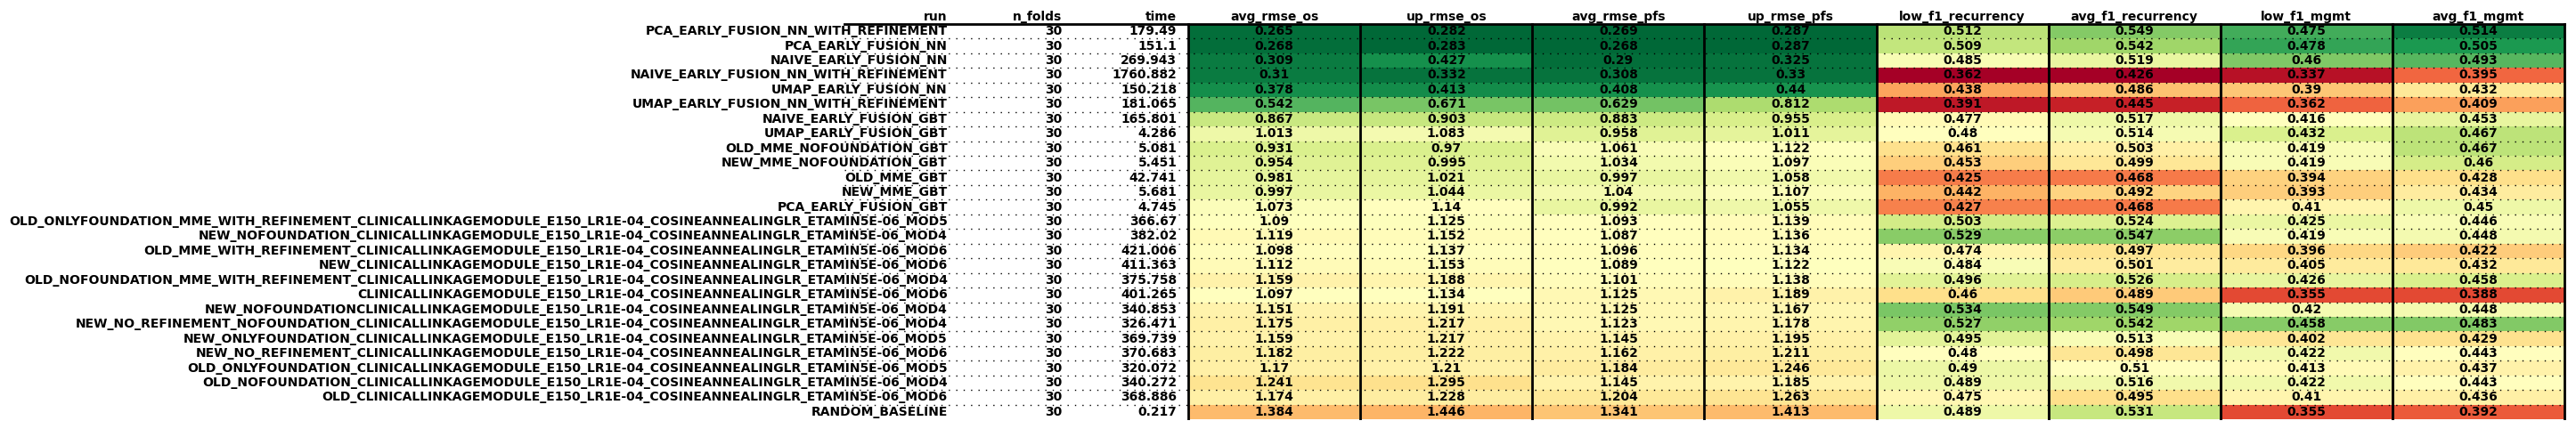

In [23]:
plot_cv_table('../results/cv_results.csv', save=True, out_file="results/cv_results_table.pdf")

## Save ClinicalLinkageModule

In [24]:
save_model(clm, '../saved_models/new_onlyFoundation_clm.ckpt')


Model saved at path: /home/sagemaker-user/gbm_hackathon/saved_models/new_onlyFoundation_clm.ckpt
Model config saved at cfg_path: /home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_onlyFoundation_clm.ckpt
You can load it by doing loaded_model = load_model(model_class, path, cfg_path, device)


(PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/new_onlyFoundation_clm.ckpt'),
 PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_onlyFoundation_clm.ckpt'))

## Without Refinement

In [25]:
refinement_cfg = None

In [26]:
cv_scores = {task:[] for task in predictive_cfg["heads_configs"].keys()}
t0 = time.time()
for train_loader, val_loader in get_mccv_loaders(dataset_II, 
                                                 collate_predictive,
                                                 n_splits=n_splits, 
                                                 test_size=test_size, 
                                                 train_batch_size=t_batch, 
                                                 val_batch_size=v_batch, 
                                                 device=device, 
                                                 random_state=random_state):
    EPOCHS_II = 150
    base_lr_II = 1e-4
    eta_min_coef = 0.05
    scheduler_II_class = torch.optim.lr_scheduler.CosineAnnealingLR
    scheduler_II_cfg = {"T_max":EPOCHS_II,
                        "eta_min":"dynamic"}
    clm = ClinicalLinkageModule(refinement_cfg=refinement_cfg,
                            predictive_cfg=predictive_cfg)
    # Optimization for Phase II
    optimizer_II = Adam(clm.parameters(), lr=base_lr_II)
    scheduler_II_cfg["optimizer"] = optimizer_II
    if "eta_min" in scheduler_II_cfg.keys():
        if scheduler_II_cfg["eta_min"] == "dynamic":
            scheduler_II_cfg["eta_min"] = eta_min_coef * base_lr_II
    scheduler_II = instantiate(scheduler_II_cfg, scheduler_II_class)

    # Training loop with validation at the end of each epoch on the validation set
    new_predictive_learning(mme, clm, 
                          train_loader,
                          EPOCHS_II, 
                          base_lr_II, 
                          optimizer_II,
                          scheduler_II,
                          clf_targets_dict,
                          v_dataloader=val_loader,
                          reg_loss_fn = nn.MSELoss(),
                          clf_loss_fn = nn.CrossEntropyLoss(),
                          batch_all=batch_all, # No worries, it is used in eval mode under the hood so not seen by model
                          make_gifs=False,
                          )
    # Evaluation metrics are computed on the validation set after training.
    clm.eval()
    all_val_predictions = {task:[] for task in predictive_cfg["heads_configs"].keys()}
    all_val_targets = {task:[] for task in predictive_cfg["heads_configs"].keys()}
    for batch in val_loader:
        patient_ids, modalities, X_dict, avail_mods, batch_targets, targets_names = batch
        
        contrastive_outputs = mme(X_dict)
        task_outputs, patient_embeddings = clm(contrastive_outputs, avail_mods)
        
        overall_loss = torch.tensor(0, device=device)
        # Regression losses
        for i, key in enumerate(task_outputs.keys()):
            if key not in clf_targets:
                all_val_predictions[key].append(task_outputs[key].squeeze())
                all_val_targets[key].append(batch_targets[:,i])
            
        # Classification losses
        for i, key in enumerate(clf_targets):
            if i == 0:
                start_idx = len(task_outputs.keys()) - len(clf_targets)
            else:
                start_idx = end_idx - 1 # last end_idx
            # clf_targets_dict is a dict that maps each clf target to the number of classes it holds
            end_idx = start_idx + clf_targets_dict[key]
            all_val_predictions[key].append(task_outputs[key])
            all_val_targets[key].append(batch_targets[:,start_idx:end_idx])
            
    for task in all_val_predictions.keys():
        all_task_pred = torch.cat(all_val_predictions[task], dim=0).to(dataset.device)
        all_task_true = torch.cat(all_val_targets[task], dim=0).to(dataset.device)
        if task not in clf_targets:
            score = torch.sqrt(nn.MSELoss()(all_task_pred, all_task_true)).item()
        else:
            score = f1_score(torch.argmax(all_task_true, dim=1).cpu().detach().numpy(), 
                             torch.argmax(all_task_pred, dim=1).cpu().detach().numpy(), 
                             average='weighted', zero_division=0)
        cv_scores[task].append(score)
reg_dict = {key:val for key, val in cv_scores.items() if key in ['os', 'pfs']}
clf_dict = {key:val for key, val in cv_scores.items() if key in clf_targets}
runtime = time.time() - t0

Using device(prediction head) : cuda
Using device(prediction head) : cuda
Using device(prediction head) : cuda
Using device(prediction head) : cuda
EPOCH 1 TOTAL TRAINING LOSS: 7.3618
EPOCH 2 TOTAL TRAINING LOSS: 6.279423
EPOCH 3 TOTAL TRAINING LOSS: 5.758535
EPOCH 4 TOTAL TRAINING LOSS: 4.929660
EPOCH 5 TOTAL TRAINING LOSS: 4.897666
EPOCH 6 TOTAL TRAINING LOSS: 4.440287
EPOCH 7 TOTAL TRAINING LOSS: 4.333742
EPOCH 8 TOTAL TRAINING LOSS: 3.860420
EPOCH 9 TOTAL TRAINING LOSS: 3.872884
EPOCH 10 TOTAL TRAINING LOSS: 3.91183
EPOCH 11 TOTAL TRAINING LOSS: 3.451452
EPOCH 12 TOTAL TRAINING LOSS: 3.720028
EPOCH 13 TOTAL TRAINING LOSS: 2.824700
EPOCH 14 TOTAL TRAINING LOSS: 3.617939
EPOCH 15 TOTAL TRAINING LOSS: 3.326360
EPOCH 16 TOTAL TRAINING LOSS: 3.013339
EPOCH 17 TOTAL TRAINING LOSS: 3.084206
EPOCH 18 TOTAL TRAINING LOSS: 3.036419
EPOCH 19 TOTAL TRAINING LOSS: 2.889367
EPOCH 20 TOTAL TRAINING LOSS: 3.127249
EPOCH 21 TOTAL TRAINING LOSS: 2.729895
EPOCH 22 TOTAL TRAINING LOSS: 2.621990
EPOCH 

In [27]:
run_name = build_run_name(
    model=clm,
    epochs=EPOCHS_II,
    base_lr=base_lr_II,
    eta_min_coef=eta_min_coef,
    scheduler_class=scheduler_II_class,
    scheduler_cfg=scheduler_II_cfg,
    contrastive_loss_cfg=None,
    modality_list=list(name_emb_dict.keys())
)

In [28]:
get_cv_results(reg_dict, clf_dict, 'new_no_refinement_onlyFoundation_' + run_name, time=runtime, save=True)

,run,n_folds,time,low_rmse_os,avg_rmse_os,up_rmse_os,low_rmse_pfs,avg_rmse_pfs,up_rmse_pfs,low_f1_recurrency,avg_f1_recurrency,up_f1_recurrency,low_f1_mgmt,avg_f1_mgmt,up_f1_mgmt,sum_reg_avg,sum_clf_avg,sum_reg_ci_relative_width,sum_clf_ci_relative_width
0,new_no_refinement_onlyFoundation_ClinicalLinka...,30,322.084634,1.202247,1.247473,1.304345,1.159097,1.216387,1.284845,0.483094,0.501988,0.520991,0.415173,0.441097,0.465119,2.463859,0.943085,0.185222,0.188726


## **Results**

In [29]:
evaluations = {}
for task in cv_scores.keys():
    evaluations[task] = np.mean(cv_scores[task])
    print(f"MCCV score on task {task}: {evaluations[task]}")

MCCV score on task os: 1.2474725802739461
MCCV score on task pfs: 1.2163867553075154
MCCV score on task recurrency: 0.5019877150062088
MCCV score on task mgmt: 0.44109731221721016


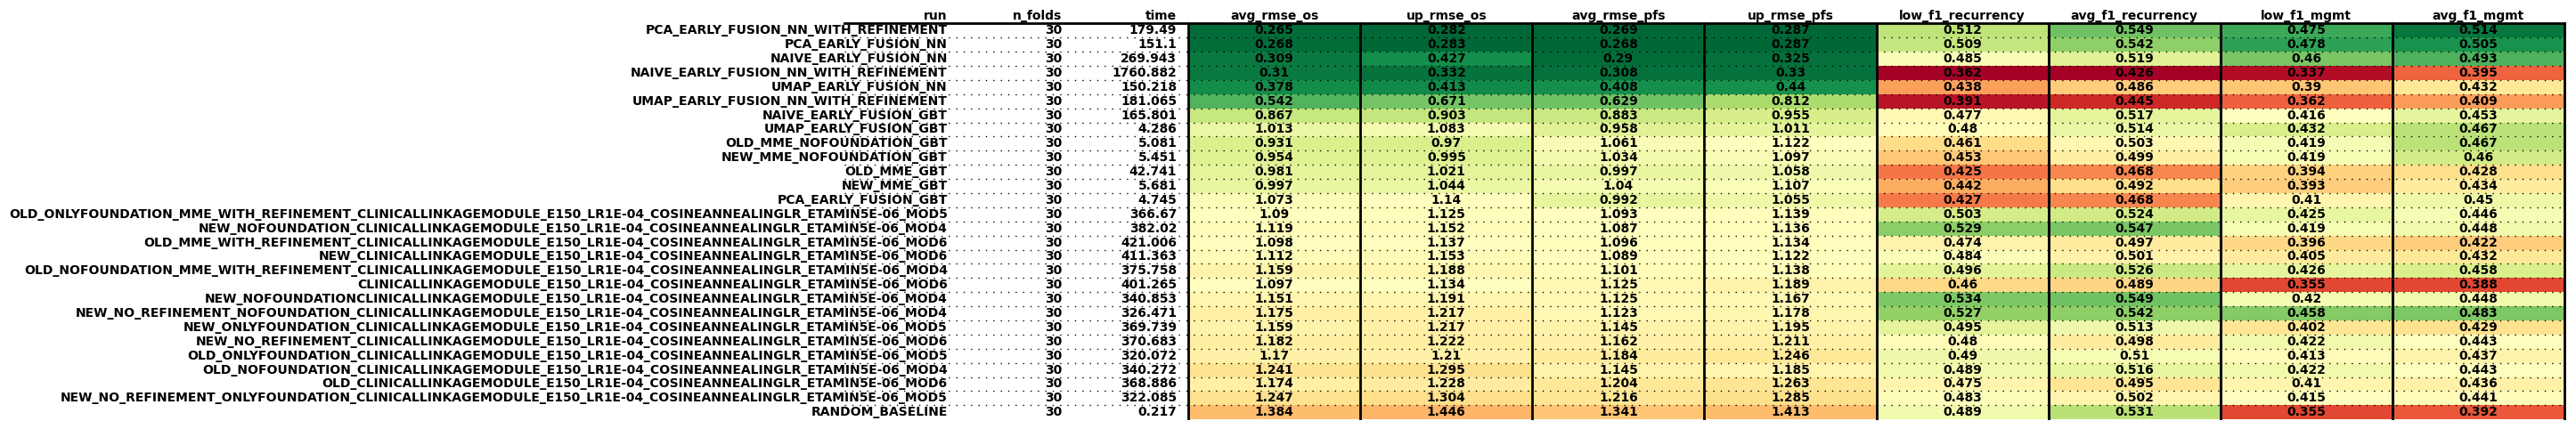

In [30]:
plot_cv_table('../results/cv_results.csv', save=True, out_file="results/cv_results_table.pdf")

## Save ClinicalLinkageModule

In [31]:
save_model(clm, '../saved_models/new_onlyFoundation_clm_no_refinement.ckpt')


Model saved at path: /home/sagemaker-user/gbm_hackathon/saved_models/new_onlyFoundation_clm_no_refinement.ckpt
Model config saved at cfg_path: /home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_onlyFoundation_clm_no_refinement.ckpt
You can load it by doing loaded_model = load_model(model_class, path, cfg_path, device)


(PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/new_onlyFoundation_clm_no_refinement.ckpt'),
 PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_onlyFoundation_clm_no_refinement.ckpt'))